# 0.0. Configure

In [2]:
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

# 1.0. Imports

In [3]:
from typing import Annotated, Literal

from IPython.display import Image, display
from langchain_core.tools import tool

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_experimental.utilities import PythonREPL
from langgraph.types import Command

from typing_extensions import TypedDict

# 2.0. Hands-On

In [4]:
ddgo_tool = DuckDuckGoSearchResults(max_results=3)

In [5]:
python_tool = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = python_tool.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"

    result_str = f"Successfully executed:\n\`\`\`python\n{code}\n\`\`\`\nStdout: {result}"

    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

In [6]:
system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    f" following workers: ['researcher', 'coder']. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)

In [7]:
class Router(TypedDict):
    """Worker router for the supervisor."""
    next: Literal["researcher", "coder", "FINISH"]

In [8]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [9]:
class State(MessagesState):
    next: str

In [10]:
def supervisor_node(state: State) -> Command[Literal["researcher", "coder", "__end__"]]:
    messages = [
        {"role": "system", "content": system_prompt},
    ] + state["messages"]

    response = llm.with_structured_output(Router).invoke(messages)
    goto = response["next"]

    if goto == "FINISH":
        goto = END

    return Command(goto=goto, update={"next": goto})

In [11]:
research_agent = create_react_agent(
    llm, tools=[ddgo_tool], state_modifier="You are a researcher. DO NOT do any math."
)

def research_node(state: State) -> Command[Literal["supervisor"]]:
    result = research_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="researcher")
            ]
        },
        goto="supervisor",
    )

In [12]:
code_agent = create_react_agent(llm, tools=[python_repl_tool])

def code_node(state: State) -> Command[Literal["supervisor"]]:
    result = code_agent.invoke(state)
    return Command(
        update={
            "messages": [
                HumanMessage(content=result["messages"][-1].content, name="coder")
            ]
        },
        goto="supervisor",
    )

In [13]:
builder = StateGraph(State)

builder.add_edge(START, "supervisor")
builder.add_node("supervisor", supervisor_node)
builder.add_node("researcher", research_node)
builder.add_node("coder", code_node)

graph = builder.compile()

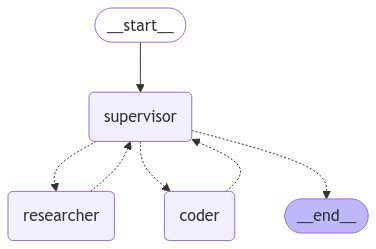

In [14]:
display(Image(graph.get_graph().draw_mermaid_png()))

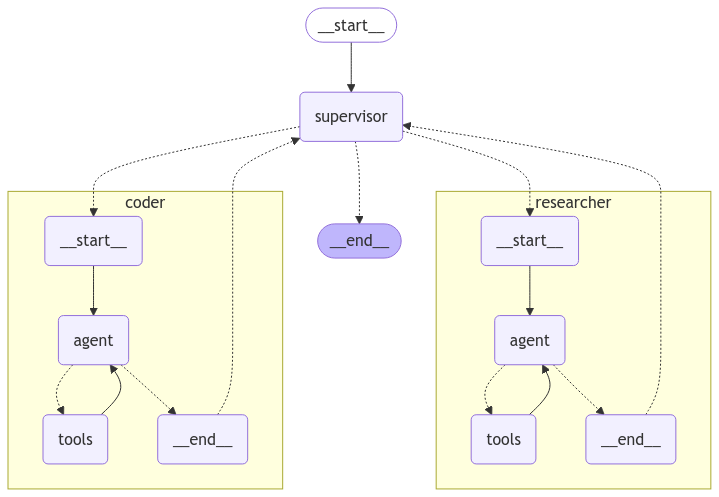

In [16]:
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

# 3.0. Testing

In [17]:
for s in graph.stream(
    {"messages": [("user", "What's the square root of 42?")]}, subgraphs=True
):
    print(s)
    print("----")

((), {'supervisor': {'next': 'researcher'}})
----
(('researcher:4c7c5255-92c5-0f34-8216-751a6a7959b7',), {'agent': {'messages': [AIMessage(content="I can't perform mathematical calculations, but I can assist you with information or explanations about square roots if you'd like!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 93, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_72ed7ab54c', 'finish_reason': 'stop', 'logprobs': None}, id='run-5fe3ad84-81cf-4f5d-8bec-561416996f14-0', usage_metadata={'input_tokens': 93, 'output_tokens': 24, 'total_tokens': 117, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}})
----
((), {

Python REPL can execute arbitrary code. Use with caution.


(('coder:3e0167df-4ff9-a757-e293-6deb1b32a889',), {'agent': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_LnUtrZMUUnOBRqlt440Z5vl3', 'function': {'arguments': '{"code":"import math\\nmath.sqrt(42)"}', 'name': 'python_repl_tool'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 122, 'total_tokens': 146, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_bd83329f63', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-e8cad4e4-769d-4c80-b0a0-a65c15b9b600-0', tool_calls=[{'name': 'python_repl_tool', 'args': {'code': 'import math\nmath.sqrt(42)'}, 'id': 'call_LnUtrZMUUnOBRqlt440Z5vl3', 'type': 'tool_call'}], usage_metadata={'input_tokens': 122, 'output_tokens': 2